In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

print("Torch version:", torch.__version__)
print("Environment OK")

Torch version: 2.10.0+cpu
Environment OK


In [2]:
dataset = load_dataset("ms_marco", "v2.1")

README.md: 0.00B [00:00, ?B/s]

C:\Users\gioia.zheng\anaconda3\envs\msmarco\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gioia.zheng\.cache\huggingface\hub\datasets--ms_marco. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


v2.1/validation-00000-of-00001.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

v2.1/train-00000-of-00007.parquet:   0%|          | 0.00/240M [00:00<?, ?B/s]

v2.1/train-00001-of-00007.parquet:   0%|          | 0.00/240M [00:00<?, ?B/s]

...

v2.1/train-00006-of-00007.parquet:   0%|          | 0.00/244M [00:00<?, ?B/s]

v2.1/test-00000-of-00001.parquet:   0%|          | 0.00/204M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/101093 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/808731 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/101092 [00:00<?, ? examples/s]

In [3]:
dataset

DatasetDict({
    validation: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 101093
    })
    train: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 808731
    })
    test: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 101092
    })
})

In [4]:
dataset["train"][0]

{'answers': ['The immediate impact of the success of the manhattan project was the only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.'],
 'passages': {'is_selected': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  'passage_text': ['The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.',
   'The Manhattan Project and its atomic bomb helped bring an end to World War II. Its legacy of peaceful uses of atomic energy continues to have an impact on history and science.',
   'Essay on The Manhattan Project - The Manhattan Project The Manhattan Project was to see if making an atomic bomb possible. The success of th

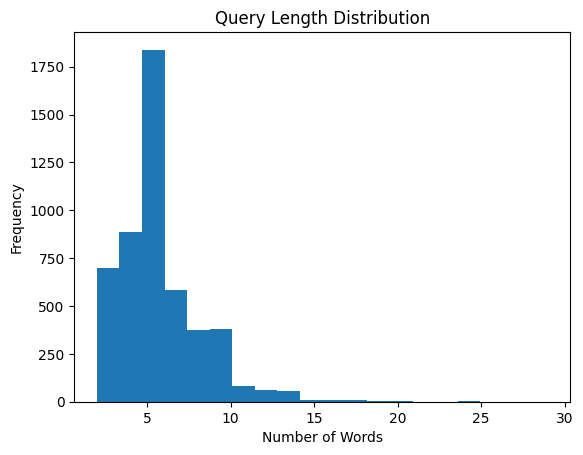

In [5]:
queries = [x["query"] for x in dataset["train"].select(range(5000))]
lengths = [len(q.split()) for q in queries]

plt.hist(lengths, bins=20)
plt.title("Query Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

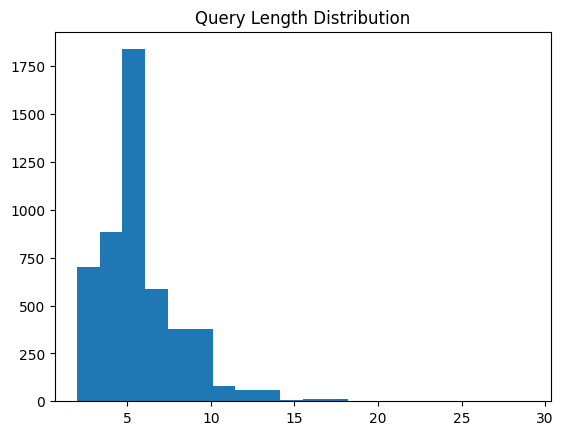

In [6]:
plt.hist(lengths, bins=20)
plt.title("Query Length Distribution")
plt.savefig("../reports/query_length_distribution.png")
plt.show()

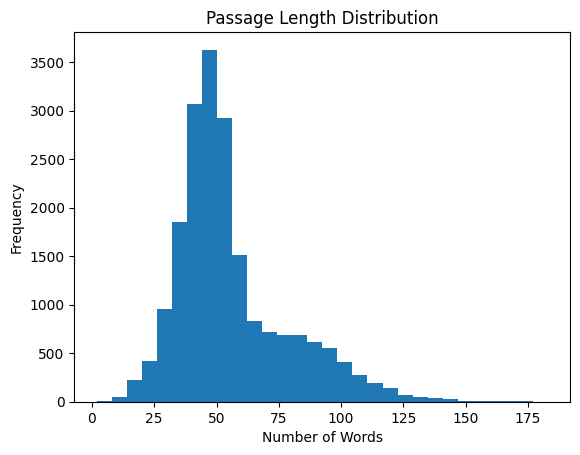

In [7]:
passages = []

sample = dataset["train"].select(range(2000))

for x in sample:
    for p in x["passages"]["passage_text"]:
        passages.append(p)

lengths = [len(p.split()) for p in passages]

plt.hist(lengths, bins=30)
plt.title("Passage Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [8]:
plt.savefig("../reports/passage_length_distribution.png")

<Figure size 640x480 with 0 Axes>

In [9]:
from collections import Counter

queries = [x["query"] for x in dataset["train"].select(range(5000))]

words = []

for q in queries:
    words.extend(q.lower().split())

counter = Counter(words)

counter.most_common(20)

[('what', 1847),
 ('is', 1455),
 ('a', 914),
 ('how', 723),
 ('in', 722),
 ('of', 702),
 ('the', 648),
 ('to', 584),
 ('does', 428),
 ('for', 383),
 ('are', 336),
 ('definition', 259),
 ('do', 239),
 ('can', 156),
 ('and', 153),
 ('on', 153),
 ('cost', 143),
 ('number', 142),
 ('county', 142),
 ('an', 136)]

In [10]:
answers = [x["answers"][0] if len(x["answers"])>0 else "" 
           for x in dataset["train"].select(range(5000))]

short = 0
sentence = 0
numeric = 0

for a in answers:
    if any(char.isdigit() for char in a):
        numeric += 1
    elif len(a.split()) <= 3:
        short += 1
    else:
        sentence += 1

print("Short answers:", short)
print("Sentence answers:", sentence)
print("Numeric answers:", numeric)

Short answers: 2462
Sentence answers: 1669
Numeric answers: 869
